# 2.12 Lab: Classifcation & Performance Measures

## Classifcation

1. Loading the data:
In this lab, we are going to use one of Scikit-Learn's built-in "toy" datasets - see https://scikit-learn.org/stable/datasets/toy_dataset.html#optical-recognition-of-handwritten-digits-dataset for details.

2.
Load the digits dataset and access the data and target variables as follows:

from sklearn import datasets

digits = datasets.load_digits()

digX = digits['data']

digy = digits['target']

In [1]:
import sklearn
from sklearn import datasets
digits = datasets.load_digits()
digX = digits['data']
digy = digits['target']

3.

Visualise the data:
Visualise a few of the numbers. You can either adapt the code in the Scikit-Learn documention: https://scikit-learn.org/stable/modules/generated/sklearn.datasets.load_digits.html or from the book's GitHub page for the chapter https://github.com/ageron/handson-ml2/blob/master/03_classification.ipynb
The approaches are slightly different. Try to understand both.

In [2]:
digX

array([[ 0.,  0.,  5., ...,  0.,  0.,  0.],
       [ 0.,  0.,  0., ..., 10.,  0.,  0.],
       [ 0.,  0.,  0., ..., 16.,  9.,  0.],
       ...,
       [ 0.,  0.,  1., ...,  6.,  0.,  0.],
       [ 0.,  0.,  2., ..., 12.,  0.,  0.],
       [ 0.,  0., 10., ..., 12.,  1.,  0.]], shape=(1797, 64))

In [3]:
import matplotlib.pyplot as plt

def plot_digit(digit_data):
    image = digit_data.reshape(8,8)
    plt.imshow(image, cmap='binary')
    plt.axis("off")

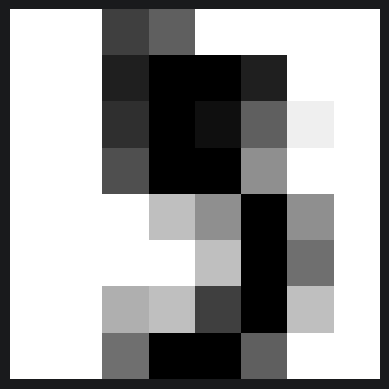

In [4]:
digit = digX[5]
plot_digit(digit)
plt.show()

4.

Build a binary classifier:
We are going to build a binary classifier purely for the purposes of exploring the performance measures. We're going to take the same approach as the book here of initially aiming to identify one digit - the book choose "5" but obviously you can pick any number. Split your data into a training and a test set, and then prepare your target variable according to which digit you are going to classify.
The only classifier we've looked at in any detail is Logistic Regression, so let's use that! We're going to keep things really simple and just use the default parameters. X and y will obviously need to be modified to the names of your training data:

from sklearn.linear_model import LogisticRegression
clf = LogisticRegression()
clf.fit(X, y)

This may give you some warnings about failing to converge but don't worry about that - we're not looking to build the perfect classifier at the moment.
You can then make predictions using this by (where X is your test data):

clf.predict(X)

In [5]:
# train test split
X_train, X_test, y_train, y_test = digX[:1500], digX[1500:], digy[:1500], digy[1500:]

# Binary labels: digit 5 vs. not 5
y_train_5 = (y_train == 5)
y_test_5 = (y_test == 5)

In [6]:
from sklearn.linear_model import LogisticRegression
c_lr = LogisticRegression()
c_lr.fit(X_train, y_train_5)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [7]:
lr_predicts = c_lr.predict(X_test)

## Performance Measures

1.

Evaluating your classifier:
Store the results of your predictions and then look at the performance by investigating the confusion matrix https://scikit-learn.org/stable/modules/generated/sklearn.metrics.confusion_matrix.html

from sklearn.metrics import confusion_matrix
confusion_matrix(your_test_data, your_predictions)

Next, import precision_score, recall_score, and f1_score from sklearn.metrics and calculate these. Are they what you expect from your confusion matrix?

In [8]:
from sklearn.metrics import confusion_matrix
confusion_matrix(y_test_5, lr_predicts)

array([[264,   3],
       [  0,  30]])

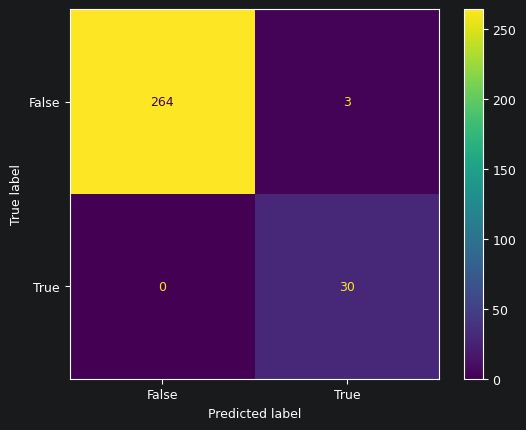

In [9]:
from sklearn.metrics import ConfusionMatrixDisplay
plt.rc('font', size=9)  # extra code – make the text smaller
ConfusionMatrixDisplay.from_predictions(y_test_5, lr_predicts)
plt.show()

In [10]:
from sklearn.metrics import classification_report
print(classification_report(y_test_5, lr_predicts, digits=3))

              precision    recall  f1-score   support

       False      1.000     0.989     0.994       267
        True      0.909     1.000     0.952        30

    accuracy                          0.990       297
   macro avg      0.955     0.994     0.973       297
weighted avg      0.991     0.990     0.990       297



2.

Optional Task:
If you have made good progress with this and have plenty of time then try adapting the code from the textbook GitHub page to plot the precision/recall curve.

## Precision-Recall Curve
Use the existing train/test split to train a binary classifier for digit `5` and plot its precision-recall curve.

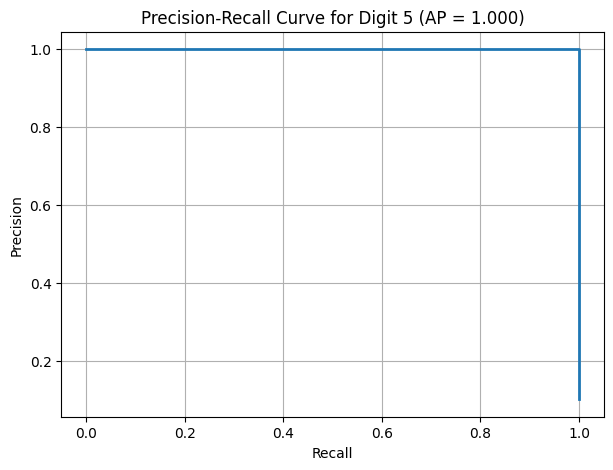

In [12]:
from sklearn.metrics import precision_recall_curve, average_precision_score

# Decision scores on the test set
y_scores = c_lr.decision_function(X_test)

# Precision-recall values
precisions, recalls, thresholds = precision_recall_curve(y_test_5, y_scores)
avg_precision = average_precision_score(y_test_5, y_scores)

# Plot
plt.figure(figsize=(7, 5))
plt.plot(recalls, precisions, linewidth=2)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title(f"Precision-Recall Curve for Digit 5 (AP = {avg_precision:.3f})")
plt.grid(True)
plt.show()


## One Versus Rest

1.

Extending our binary classifier to predict multiple classes - One Versus Rest:
Logistic Regression can be extended to deal with multiple classes but for now we're going to demonstrate the use of the One versus Rest (OVR) approach which can build a multi-class classifier from a binary one. Import the OneVsRestClassifier as follows and parameterise it to use Logistic Regression:

from sklearn.multiclass import OneVsRestClassifier
ovr_clf = OneVsRestClassifier(LogisticRegression())

In [16]:
from sklearn.multiclass import OneVsRestClassifier
ovr_c_lr = OneVsRestClassifier(LogisticRegression(max_iter=1000))

In [17]:
ovr_c_lr.fit(X_train, y_train)

,"estimator estimator: estimator objectA regressor or a classifier that implements :term:`fit`.When a classifier is passed, :term:`decision_function` will be usedin priority and it will fallback to :term:`predict_proba` if it is notavailable.When a regressor is passed, :term:`predict` is used.",LogisticRegre...max_iter=1000)
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation: the `n_classes`one-vs-rest problems are computed in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: 0.20 `n_jobs` default changed from 1 to None",None
,"verbose verbose: int, default=0The verbosity level, if non zero, progress messages are printed.Below 50, the output is sent to stderr. Otherwise, the output is sentto stdout. The frequency of the messages increases with the verbositylevel, reporting all iterations at 10. See :class:`joblib.Parallel` formore details... versionadded:: 1.1",0
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=

In [18]:
ovr_predicts = ovr_c_lr.predict(X_test)

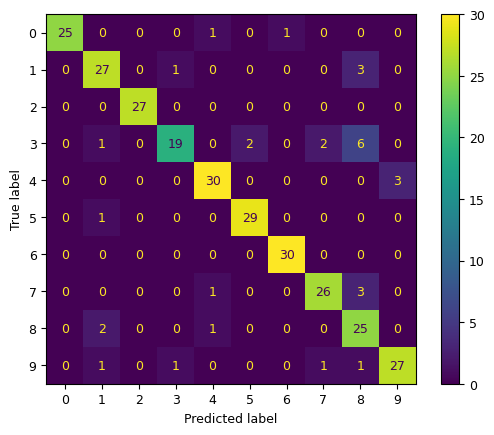

In [19]:
plt.rc('font', size=9)  # extra code – make the text smaller
ConfusionMatrixDisplay.from_predictions(y_test, ovr_predicts)
plt.show()

One versus rest trains 10 classifiers, one for each digit. The default (one vs one) has a voting system which takes longer to train but may have better results.